# Employee Salary Prediction
This notebook performs:
- Data Loading
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Model Training
- Prediction
- Visualization

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [19]:
df = pd.read_csv('Employers_data.csv')
df.head()

,Employee_ID,Name,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,1,Merle Ingram,24,Female,Engineering,Engineer,1,Master,Austin,90000
1,2,John Mayes,56,Male,Sales,Executive,33,Master,Seattle,195000
2,3,Carlos Wille,21,Male,Engineering,Intern,1,Bachelor,New York,35000
3,4,Michael Bryant,30,Male,Finance,Analyst,9,Bachelor,New York,75000
4,5,Paula Douglas,25,Female,HR,Analyst,2,Master,Seattle,70000


## Basic Information

In [20]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Employee_ID       10000 non-null  int64
 1   Name              10000 non-null  str  
 2   Age               10000 non-null  int64
 3   Gender            10000 non-null  str  
 4   Department        10000 non-null  str  
 5   Job_Title         10000 non-null  str  
 6   Experience_Years  10000 non-null  int64
 7   Education_Level   10000 non-null  str  
 8   Location          10000 non-null  str  
 9   Salary            10000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 781.4 KB


,Employee_ID,Age,Experience_Years,Salary
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.455900,12.370900,115381.500000
std,2886.89568,10.000213,9.148951,46066.139047
min,1.00000,21.000000,0.000000,25000.000000
25%,2500.75000,27.000000,5.000000,70000.000000
50%,5000.50000,34.000000,10.000000,120000.000000
75%,7500.25000,43.000000,19.000000,150000.000000
max,10000.00000,60.000000,37.000000,215000.000000


## Data Cleaning

In [21]:
df = df.drop(['Employee_ID','Name'], axis=1)
df.isnull().sum()

Age                 0
Gender              0
Department          0
Job_Title           0
Experience_Years    0
Education_Level     0
Location            0
Salary              0
dtype: int64

## Encoding Categorical Columns

In [22]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns: df[col] = le.fit_transform(df[col])

df.head()

C:\Users\cs\AppData\Local\Temp\ipykernel_2612\1821911202.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns: df[col] = le.fit_transform(df[col])


,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,24,0,0,1,1,1,0,90000
1,56,1,5,2,33,1,4,195000
2,21,1,0,3,1,0,2,35000
3,30,1,1,0,9,0,2,75000
4,25,0,2,0,2,1,4,70000


## Split Features and Target

In [23]:
X = df.drop('Salary', axis=1)
y = df['Salary']

## Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Model

In [25]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## Predictions

In [26]:
pred = model.predict(X_test)

## Model Evaluation

In [27]:
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print('MSE:', mse)
print('R2 Score:', r2)

MSE: 24208828.131576072
R2 Score: 0.988513894446375


## Actual vs Predicted Graph

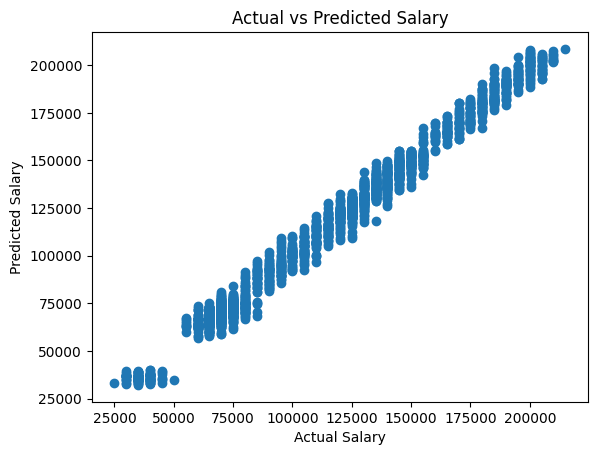

In [28]:
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.show()

In [29]:
import pickle
with open("salary_prediction_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [30]:
df

,Age,Gender,Department,Job_Title,Experience_Years,Education_Level,Location,Salary
0,24,0,0,1,1,1,0,90000
1,56,1,5,2,33,1,4,195000
2,21,1,0,3,1,0,2,35000
3,30,1,1,0,9,0,2,75000
4,25,0,2,0,2,1,4,70000
...,...,...,...,...,...,...,...,...
9995,51,1,5,2,28,1,0,185000
9996,36,0,5,2,9,2,3,165000
9997,57,1,5,2,30,2,2,200000
9998,37,0,0,4,14,1,2,135000
